In [6]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Add project root to python path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.config import RAW_DATA_PATH
from src.utils import load_dataset

# Load the dataset
df = load_dataset(RAW_DATA_PATH)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


In [7]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

df.shape

Number of Rows : 545
Number of Columns : 10


(545, 10)

In [8]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning']

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   price            545 non-null    int64
 1   area             545 non-null    int64
 2   bedrooms         545 non-null    int64
 3   bathrooms        545 non-null    int64
 4   stories          545 non-null    int64
 5   mainroad         545 non-null    str  
 6   guestroom        545 non-null    str  
 7   basement         545 non-null    str  
 8   hotwaterheating  545 non-null    str  
 9   airconditioning  545 non-null    str  
dtypes: int64(5), str(5)
memory usage: 49.0 KB


In [9]:
df.describe()

,price,area,bedrooms,bathrooms,stories
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000


In [10]:
missing = df.isnull().sum()

missing

price              0
area               0
bedrooms           0
bathrooms          0
stories            0
mainroad           0
guestroom          0
basement           0
hotwaterheating    0
airconditioning    0
dtype: int64

In [11]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [12]:
df.dtypes

price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
mainroad             str
guestroom            str
basement             str
hotwaterheating      str
airconditioning      str
dtype: object

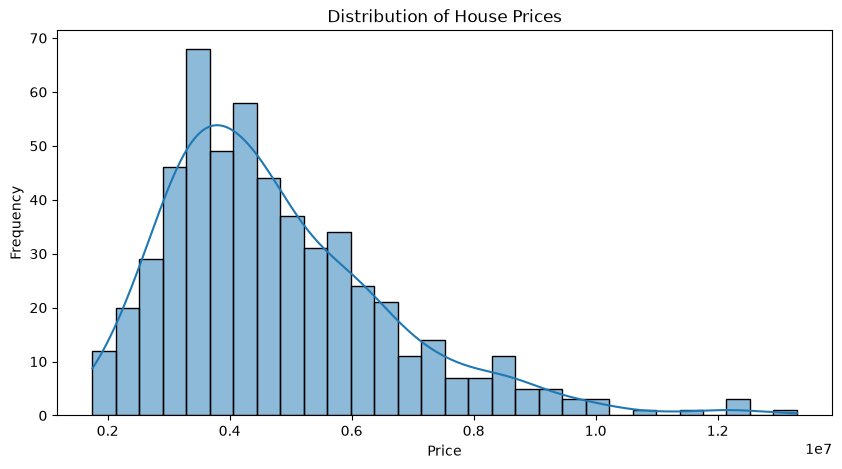

In [13]:
plt.figure(figsize=(10, 5))

sns.histplot(df["price"], bins=30, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [14]:
corr = df.corr(numeric_only=True)

corr

,price,area,bedrooms,bathrooms,stories
price,1.000000,0.535997,0.366494,0.517545,0.420712
area,0.535997,1.000000,0.151858,0.193820,0.083996
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165
stories,0.420712,0.083996,0.408564,0.326165,1.000000


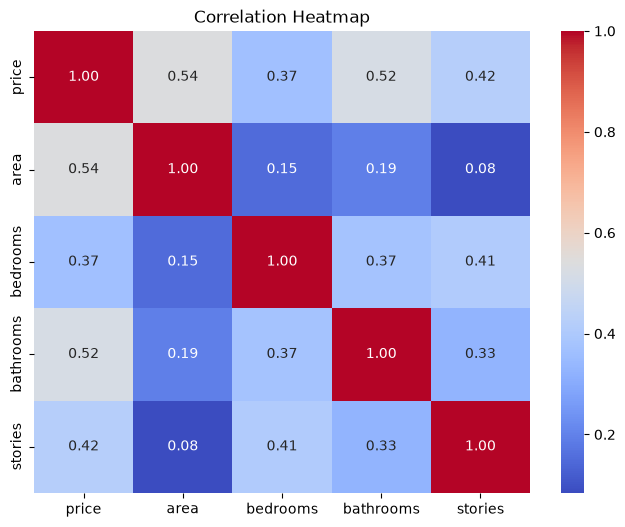

In [15]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

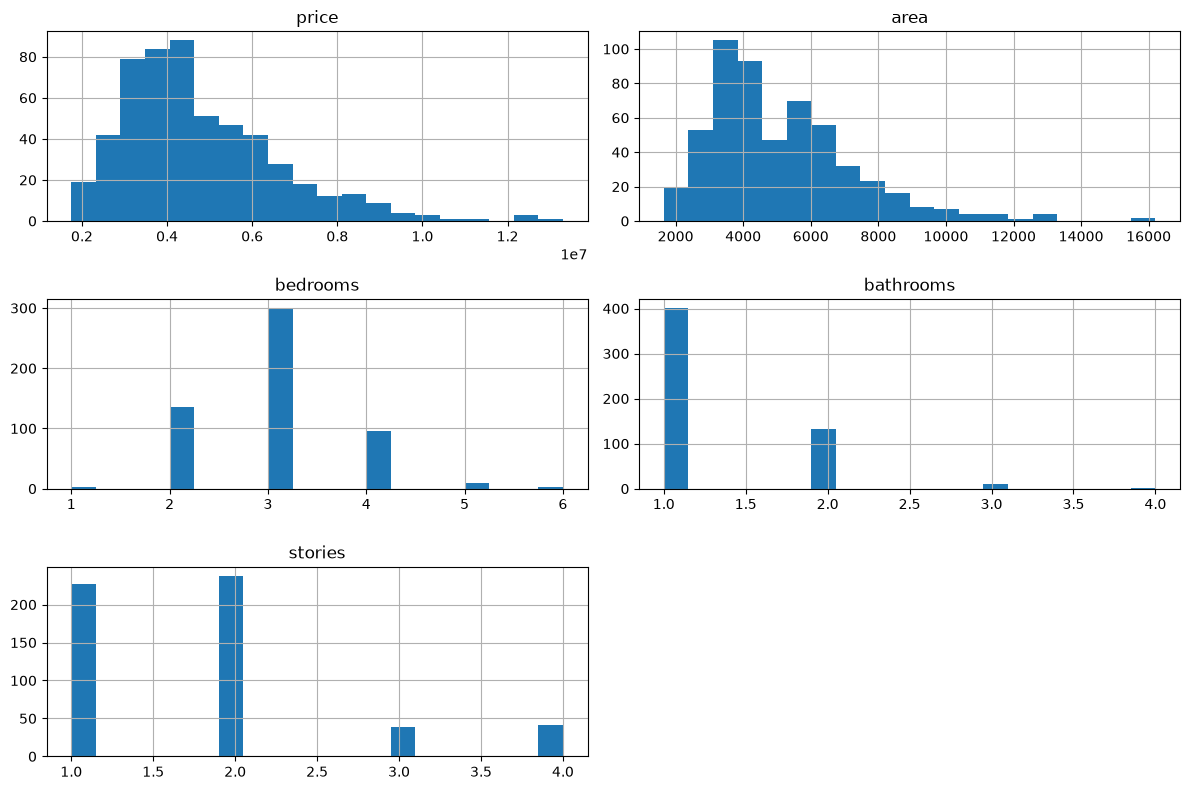

In [16]:
numeric_columns = [
    "price",
    "area",
    "bedrooms",
    "bathrooms",
    "stories"
]

df[numeric_columns].hist(
    figsize=(12, 8),
    bins=20
)

plt.tight_layout()

plt.show()

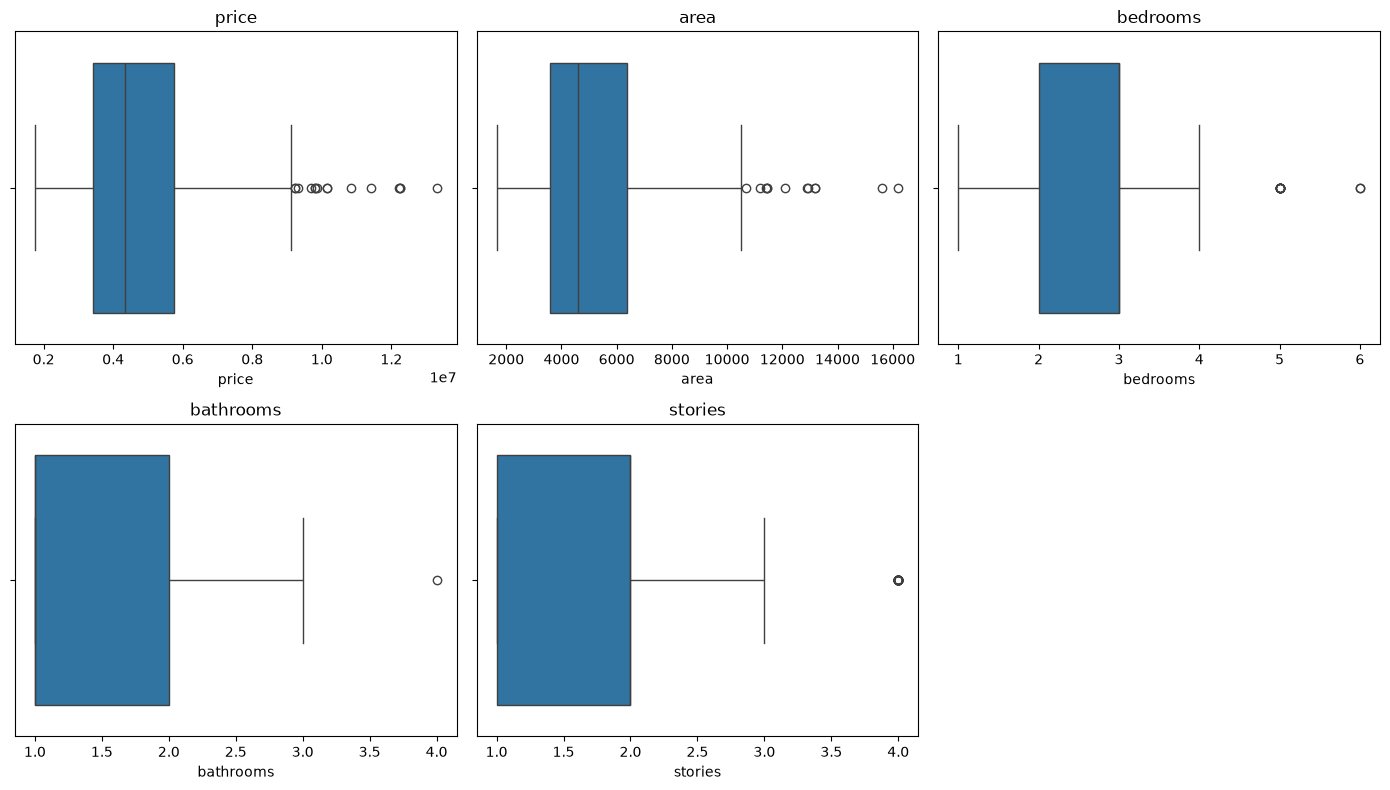

In [17]:
plt.figure(figsize=(14, 8))

for i, column in enumerate(numeric_columns, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[column])
    plt.title(column)

plt.tight_layout()

plt.show()

In [18]:
categorical_columns = df.select_dtypes(include='object').columns.tolist()

categorical_columns

C:\Users\Shashi Kumar Singh\AppData\Local\Temp\ipykernel_4032\2204068039.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns.tolist()


['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning']

In [19]:
for column in categorical_columns:
    print("=" * 40)
    print(column)
    print(df[column].value_counts())

mainroad
mainroad
yes    468
no      77
Name: count, dtype: int64
guestroom
guestroom
no     448
yes     97
Name: count, dtype: int64
basement
basement
no     354
yes    191
Name: count, dtype: int64
hotwaterheating
hotwaterheating
no     520
yes     25
Name: count, dtype: int64
airconditioning
airconditioning
no     373
yes    172
Name: count, dtype: int64


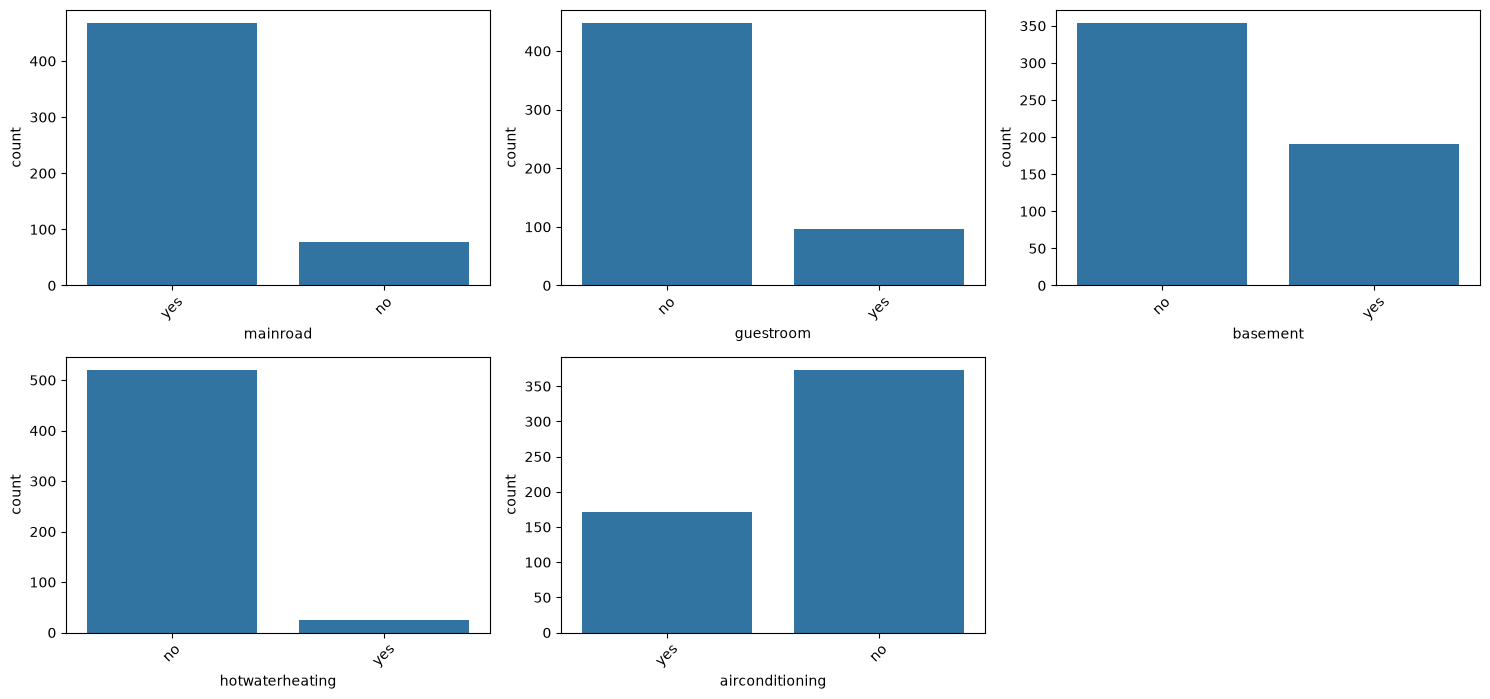

In [20]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=column)
    plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

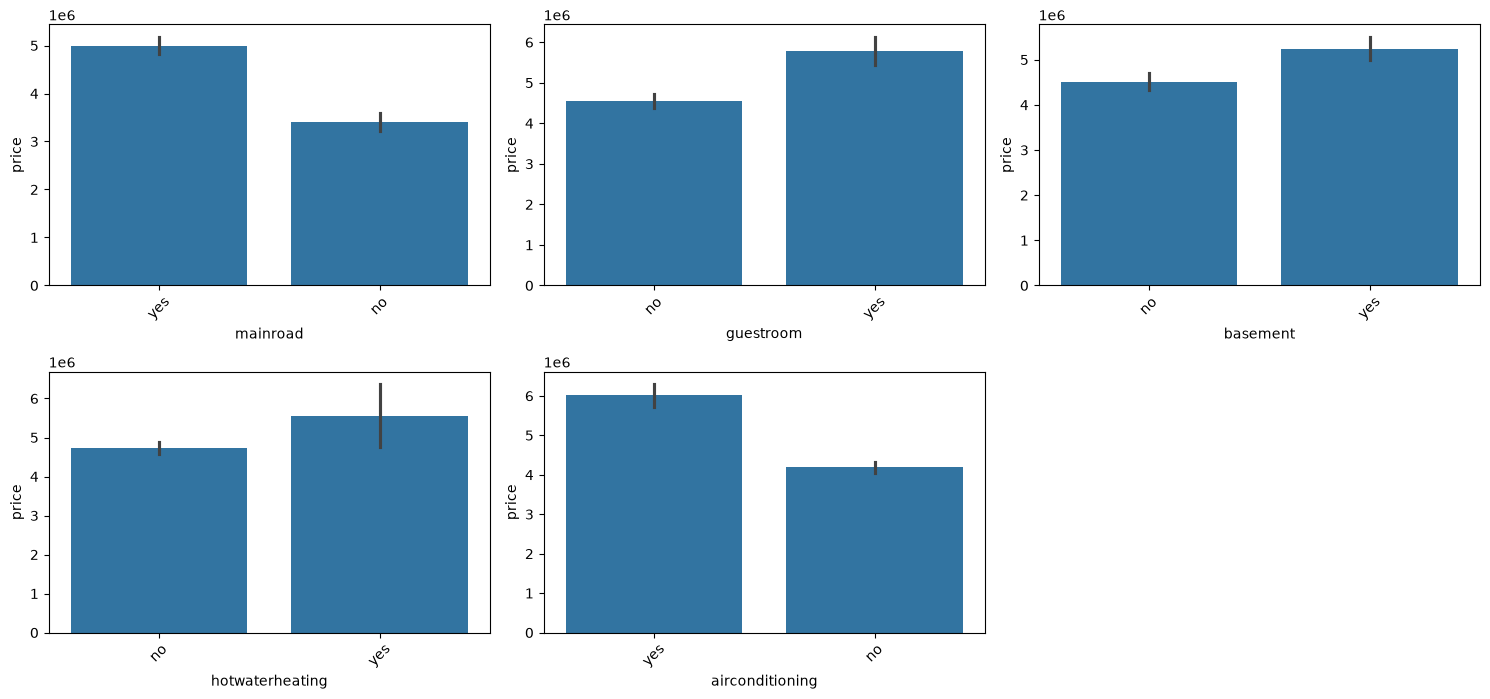

In [21]:
plt.figure(figsize=(15, 10))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(3, 3, i)
    sns.barplot(data=df, x=column, y="price", estimator="mean")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

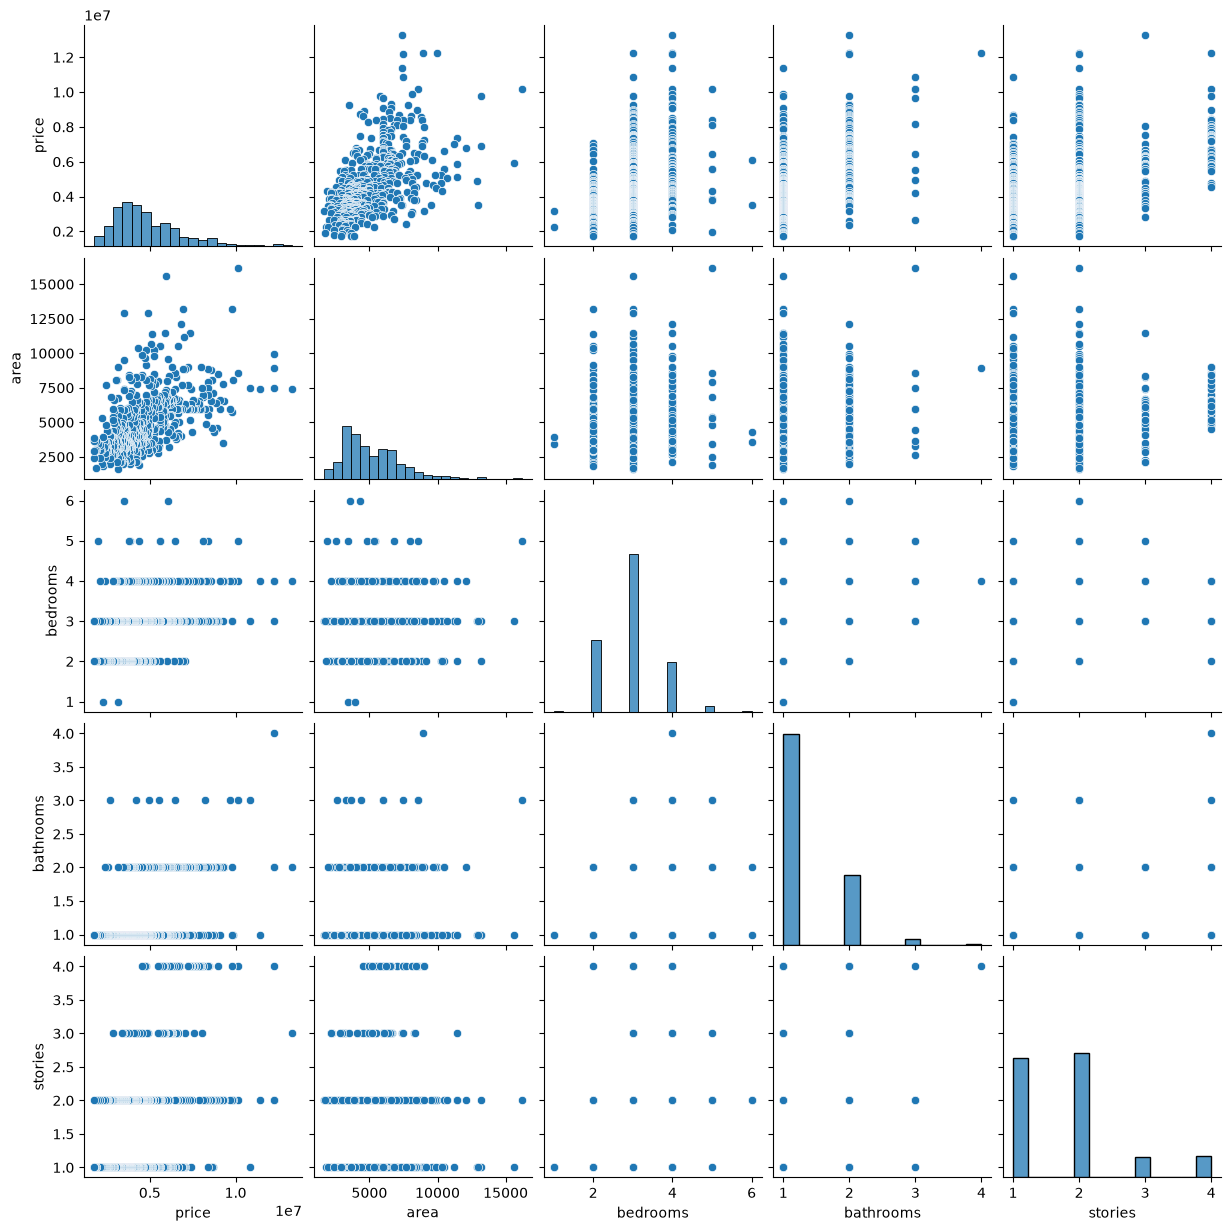

In [22]:
sns.pairplot(
    df[
        [
            "price",
            "area",
            "bedrooms",
            "bathrooms",
            "stories"
        ]
    ]
)

plt.show()

In [23]:
print("=" * 50)
print("Dataset Summary")
print("=" * 50)

print(f"Rows            :{df.shape[0]}")
print(f"column          :{df.shape[1]}")
print(f"Missing Values  :{df.isnull().sum().sum()}" )
print(f"Duplicate Rows  :{df.duplicated().sum()}")

print("\nData Types")
print(df.dtypes)

Dataset Summary
Rows            :545
column          :10
Missing Values  :0
Duplicate Rows  :0

Data Types
price              int64
area               int64
bedrooms           int64
bathrooms          int64
stories            int64
mainroad             str
guestroom            str
basement             str
hotwaterheating      str
airconditioning      str
dtype: object
